In [ ]:
# importing required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score



In [3]:
# Load data
df = pd.read_csv("dwh_sales.csv")
df["Date"] = pd.to_datetime(df["Date"])

# Aggregate daily revenue
daily_sales = (
    df.groupby("Date")["Revenue"]
      .sum()
      .reset_index()
      .sort_values("Date")
)


In [4]:
# Load data
df = pd.read_csv("dwh_sales.csv")
df["Date"] = pd.to_datetime(df["Date"])

# Aggregate daily revenue
daily_sales = (
    df.groupby("Date")["Revenue"]
      .sum()
      .reset_index()
      .sort_values("Date")
)


# Initial Model
### Minimal Feature engineering
### Default Parameters

In [6]:
# Only 1 lag feature (simple baseline)
daily_sales["lag_1"] = daily_sales["Revenue"].shift(1)
initial_df = daily_sales.dropna()

X_init = initial_df[["lag_1"]]
y_init = initial_df["Revenue"]
dates_init = initial_df["Date"]

#### TrainTest Split (80/20- Time Based) 

In [7]:
split_i = int(len(initial_df) * 0.8)

X_train_i, X_test_i = X_init.iloc[:split_i], X_init.iloc[split_i:]
y_train_i, y_test_i = y_init.iloc[:split_i], y_init.iloc[split_i:]
dates_test_i = dates_init.iloc[split_i:]


#### Train Initial random Forest Model

In [8]:
initial_model = RandomForestRegressor(
    random_state=42
)

initial_model.fit(X_train_i, y_train_i)
y_pred_i = initial_model.predict(X_test_i)


#### Evaluating Initial Model

In [9]:
mae_i = mean_absolute_error(y_test_i, y_pred_i)
rmse_i = np.sqrt(mean_squared_error(y_test_i, y_pred_i))
r2_i = r2_score(y_test_i, y_pred_i)

print("INITIAL MODEL PERFORMANCE")
print(f"MAE  : {mae_i:,.2f}")
print(f"RMSE : {rmse_i:,.2f}")
print(f"R²   : {r2_i:.3f}")


INITIAL MODEL PERFORMANCE
MAE  : 5,853.99
RMSE : 7,662.50
R²   : -0.052


#### Plot - Initial Model

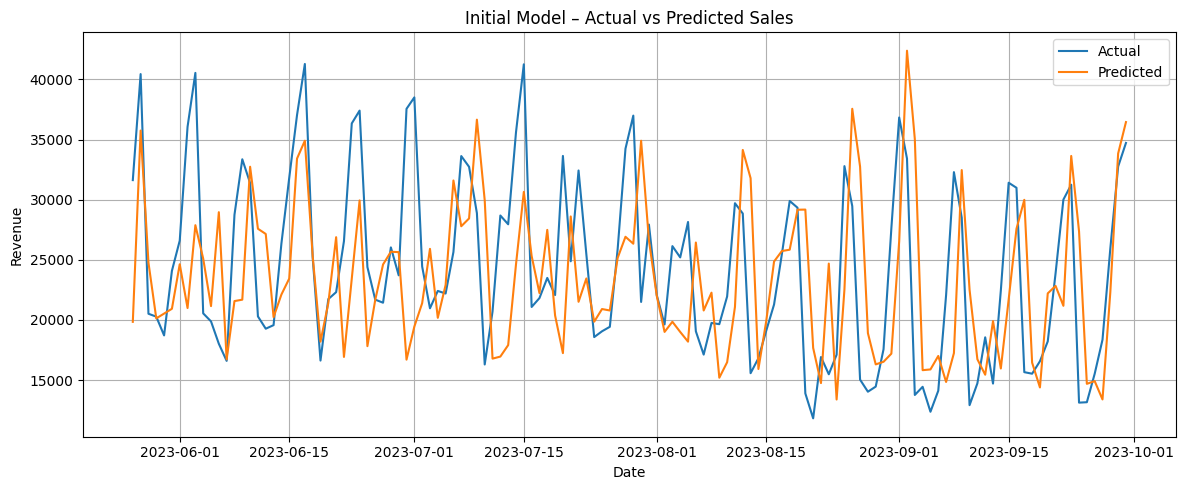

In [11]:
plt.figure(figsize=(12,5))
plt.plot(dates_test_i, y_test_i, label="Actual")
plt.plot(dates_test_i, y_pred_i, label="Predicted")
plt.title("Initial Model – Actual vs Predicted Sales")
plt.xlabel("Date")
plt.ylabel("Revenue")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# Final Modeling
#### Feature Engineering
#### Hyperparameter Tunning
#### Improved accuracy

In [12]:
daily_sales["lag_7"] = daily_sales["Revenue"].shift(7)
daily_sales["lag_14"] = daily_sales["Revenue"].shift(14)

final_df = daily_sales.dropna().reset_index(drop=True)

X_final = final_df[["lag_1", "lag_7", "lag_14"]]
y_final = final_df["Revenue"]
dates_final = final_df["Date"]

#### Function for Train/Test Split

In [19]:
def train_evaluate_final(train_ratio):
    split = int(len(final_df) * train_ratio)

    X_train, X_test = X_final.iloc[:split], X_final.iloc[split:]
    y_train, y_test = y_final.iloc[:split], y_final.iloc[split:]
    dates_test = dates_final.iloc[split:]

    model = RandomForestRegressor(
        n_estimators=300,
        max_depth=10,
        min_samples_leaf=5,
        random_state=42
    )

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    return model, {
        "Split": f"{int(train_ratio*100)}/{round((1-train_ratio)*100)}",
        "MAE": mean_absolute_error(y_test, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_test, y_pred)),
        "R2": r2_score(y_test, y_pred),
        "Dates": dates_test,
        "Actual": y_test,
        "Predicted": y_pred
    }


#### Train Final Model on 3 Different Splits

In [20]:
model_60, res_60 = train_evaluate_final(0.6)
model_70, res_70 = train_evaluate_final(0.7)
model_80, res_80 = train_evaluate_final(0.8)  # BEST MODEL


#### Final Model Performance Comparison

In [21]:
comparison_df = pd.DataFrame([
    {"Split": res_60["Split"], "MAE": res_60["MAE"], "RMSE": res_60["RMSE"], "R²": res_60["R2"]},
    {"Split": res_70["Split"], "MAE": res_70["MAE"], "RMSE": res_70["RMSE"], "R²": res_70["R2"]},
    {"Split": res_80["Split"], "MAE": res_80["MAE"], "RMSE": res_80["RMSE"], "R²": res_80["R2"]}
])

comparison_df

,Split,MAE,RMSE,R²
0,60/40,4076.476035,5818.278791,0.532253
1,70/30,3706.993367,5502.346935,0.578469
2,80/20,2998.850256,3749.370486,0.741971


#### Plot the chat - final Model

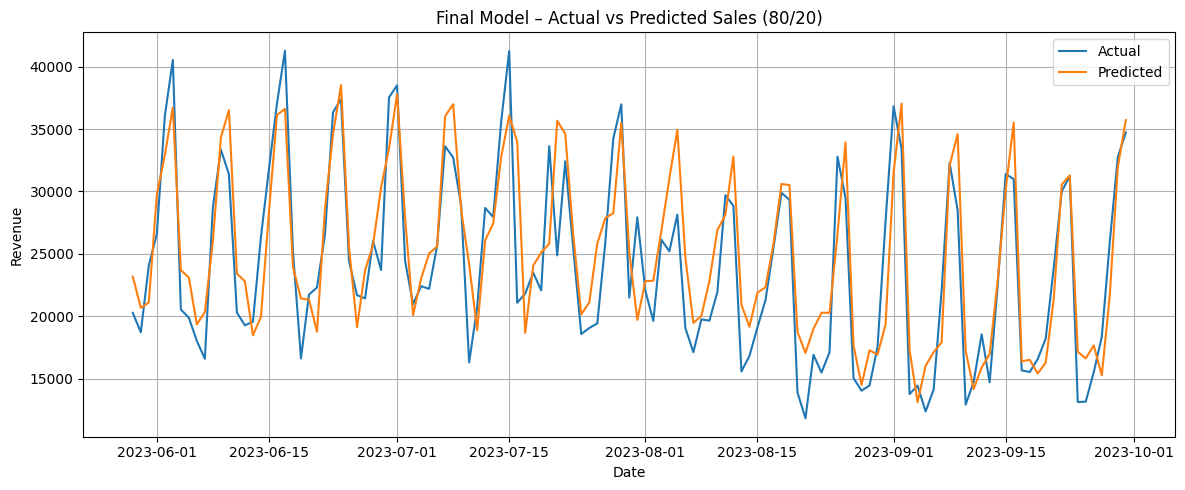

In [22]:
plt.figure(figsize=(12,5))
plt.plot(res_80["Dates"], res_80["Actual"], label="Actual")
plt.plot(res_80["Dates"], res_80["Predicted"], label="Predicted")
plt.title("Final Model – Actual vs Predicted Sales (80/20)")
plt.xlabel("Date")
plt.ylabel("Revenue")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Predicting the next 30 days

##### prepareing the last known data point

In [17]:
forecast_days = 30
forecast_df = final_df.copy()

future_dates = []
future_sales = []

last_date = forecast_df["Date"].iloc[-1]

for _ in range(forecast_days):
    X_future = pd.DataFrame([[
        forecast_df["Revenue"].iloc[-1],
        forecast_df["Revenue"].iloc[-7],
        forecast_df["Revenue"].iloc[-14]
    ]], columns=["lag_1", "lag_7", "lag_14"])

    prediction = model_80.predict(X_future)[0]
    next_date = last_date + pd.Timedelta(days=1)

    future_dates.append(next_date)
    future_sales.append(prediction)

    forecast_df = pd.concat([
        forecast_df,
        pd.DataFrame({"Date": [next_date], "Revenue": [prediction]})
    ], ignore_index=True)

    last_date = next_date


##### Plot Historical + 30 days forecast

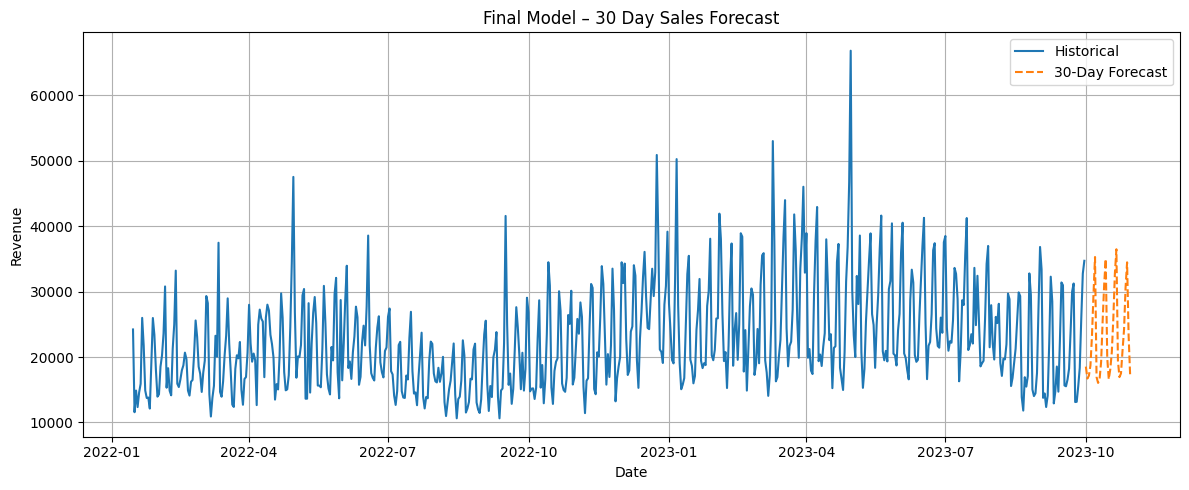

In [18]:
plt.figure(figsize=(12,5))
plt.plot(final_df["Date"], final_df["Revenue"], label="Historical")
plt.plot(future_dates, future_sales, linestyle="--", label="30-Day Forecast")
plt.title("Final Model – 30 Day Sales Forecast")
plt.xlabel("Date")
plt.ylabel("Revenue")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
